## MAR "extreme" example

In [3]:
import os
import sys
import torch
from pathlib import Path
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import argparse
import torch.nn as nn
import torch.optim as optim
import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.spatial.distance import cdist, pdist
import pandas as pd
import seaborn as sns
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import traceback
from wgf_minimal import sample_wgf_new
from hyperimpute.plugins.imputers import Imputers
import scipy

sys.path.append(str(Path("MIRI-Imputation").resolve()))
from src.imputer_wrapper import impute_now

## Enable usage of R methods
os.environ['RENV_CONFIG_AUTOLOAD_ENABLED'] = 'FALSE'
os.environ['R_PROFILE_USER'] = ''
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.packages import importr
from rpy2.robjects.conversion import localconverter

### Set parameters and load existing results if available

In [4]:
### PARAMETER VALUES ###

param_vals = {  
    ## Simulation params
    "n_runs": 50,
    
    ## Data params
    "n": 5000,
    "d": 5,
    "alpha": 0.7,
    "distr": "Normal",

    ## Resampling params
    "init": "ColBT",
    "T": 100
}
param_vals["n_new"] = param_vals["n"]

methods = ['truth', 'wgf_new', 'true_impute', 'mice_cart', 'miri']#, 'knewimp', 'knn', 'missdiff']

In [5]:
### CHECK WITH LOG FILE ###

# Define the log file path
save_dir = 'results/simulations/'
log_file = os.path.join(save_dir, 'parameter_log.csv')

# Check if the log file exists and read it
if os.path.exists(log_file):
    param_log = pd.read_csv(log_file)
else:
    param_log = pd.DataFrame(columns=['ID', 'n_runs',
                                      'n', 'd', 'alpha', 'distr',
                                      'init', 'n_new', 'T'])

# Check if the parameter setup already exists in the log file
query_str = " & ".join([f"{k} == {repr(v)}" for k, v in param_vals.items()])
matching = param_log.query(query_str) #pd.DataFrame()

if not matching.empty:
    # Load the existing results
    results_file = os.path.join(save_dir, f'results_{matching['ID'].iloc[0]:03d}.pt')
    results = torch.load(results_file, weights_only=False)
else:
    # Determine the next ID
    if param_log.empty:
        next_id = 1
    else:
        next_id = param_log['ID'].max() + 1
    results_file = os.path.join(save_dir, f'results_{next_id:03d}.pt')
    
    # Append to log file
    param_vals.update({'ID': next_id})
    param_log = pd.concat([param_log, pd.DataFrame([param_vals])], ignore_index=True)

    # Create new dict to save results
    results = {"data": {}, 
               "metrics": {}, 
               "Xhat_store": {}}

### Generate simulated dataset (if not available)

In [6]:
def sample_x2_given_x1(X1):
    if param_vals["distr"] == "UNI":
        # conditional CDF: F(x2|x1) = x2 + alpha*(2*x1-1)*(x2^2 - x2)
        # invert this to sample X2 = F_inv(U)
        # Inversion yields quadratic equation: alpha*(2*x1-1)*x2^2 + [1 - alpha*(2*x1-1)]*x2 - u = 0
        # NOTE: CDF is symmetric so the same method can be used to sample X1 given X2
        U = np.random.rand(X1.shape[0])
        a = param_vals["alpha"] * (2*X1 - 1)
        b = 1 - a
        c = -U
        X2 = np.where(np.abs(a) < 1e-10, U/b, (-b + np.sqrt(b**2 - 4*a*c)) / (2*a))
    elif param_vals["distr"] == "Normal":
        X2 = np.random.multivariate_normal(param_vals["alpha"]*X1, (1-param_vals["alpha"]**2)*np.eye(X1.shape[0]))
    else:
        raise NotImplementedError("Chosen 'distr' is not implemented yet.")
    return X2

def sample_truth(n, d):
    if param_vals["distr"] == "UNI":
        X1 = np.random.rand(n)
        X2 = sample_x2_given_x1(X1)
        data = np.column_stack([X1, X2, np.random.rand(n, d-2)])
    elif param_vals["distr"] == "Normal":
        mu = np.zeros(d)
        cov = np.eye(d)
        cov[0,1] = param_vals["alpha"]
        cov[1,0] = param_vals["alpha"]
        data = np.random.multivariate_normal(mu, cov, n) 
    else:
        raise NotImplementedError("Chosen 'distr' is not implemented yet.")
        
    Xdata = torch.from_numpy(data).float().to(device)
    X = Xdata[:n, :].detach().clone()
    return X

def impute_bootstrap_per_col(X, M):
    n, d = X.shape
    for j in range(d):
        observed_mask = M[:, j] == 1
        missing_mask = M[:, j] == 0

        observed_values = X[observed_mask, j]
        if observed_values.numel() == 0:
            raise ValueError(f"Value of column {j} is always missing. Need to be observed at least once.")

        num_missing = missing_mask.sum()
        if num_missing > 0:
            rand_idx = torch.randint(
                0, observed_values.shape[0],
                (num_missing,),
                device=X.device
            )
            X[missing_mask, j] = observed_values[rand_idx]

def generate_data(n, d, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Sample X
    X = sample_truth(n, d)
    Xstar = X.detach().clone()

    # Sample M
    if param_vals["distr"] == "UNI":
        X1 = X[:, 0]
        X2 = X[:, 1]
    elif param_vals["distr"] == "Normal":
        normal = torch.distributions.Normal(0.0, 1.0)
        X1 = normal.cdf(X[:, 0])
        X2 = normal.cdf(X[:, 1])
    else:
        raise NotImplementedError("Chosen 'distr' is not implemented yet.")
    P = torch.stack([(X1 + X2) / 3, (2 - X1) / 3, (1 - X2) / 3], dim=1)
    dist = torch.distributions.Categorical(P)
    choices = dist.sample()
    masks = torch.stack([torch.ones(d), torch.arange(d)!=1, torch.arange(d)!=0])
    M = masks[choices]

    # Substitute missing values with initial imputation
    if isinstance(param_vals["init"], (int, float)):
        X[M == 0] = param_vals["init"]
    elif param_vals["init"] == 'UNI(0,1)':
        X[M == 0] = torch.rand(n,d)[M == 0]
    elif param_vals["init"] == 'N(0.5,1)':
        X[M == 0] = torch.normal(mean=0.5, std=1, size=(n,d))[M == 0]
    elif param_vals["init"] == 'N(0,1)':
        X[M == 0] = torch.normal(mean=0, std=1, size=(n,d))[M == 0]
    elif param_vals["init"] == 'ColBT':
        impute_bootstrap_per_col(X, M)
    else:
        raise NotImplementedError("The chosen initial imputation method is not implemented.")

    return X.cpu(), M.cpu(), Xstar.cpu()

In [7]:
if not results["data"]:
    for run in range(param_vals["n_runs"]):
        X0, M, Xstar = generate_data(param_vals["n"], param_vals["d"], seed=run)
        results["data"][run] = {
            "X0": X0,
            "M": M,
            "Xstar": Xstar
        }

### Run sample methods and compute metrics (only those that are not available yet) 

In [8]:
def energy_distance(X, Y):
    XY = cdist(X, Y)
    XX = cdist(X, X)
    YY = cdist(Y, Y)
    return 2 * XY.mean() - XX.mean() - YY.mean()

def energy_distance_fixed_X(X, XX_mean, Y):
    XY_mean = cdist(X, Y).mean()
    n = len(Y)
    YY_mean = pdist(Y).mean() * (n - 1) / n
    return 2 * XY_mean - XX_mean - YY_mean

In [9]:
def impute_truth(X0, M, n_imputations):
    X_imps = []
    for draw in range(n_imputations):
        Xhat = np.asarray(X0.detach().clone())
        Xhat[M[:,0] == 0, 0] = sample_x2_given_x1(X0[M[:,0] == 0, 1].detach().numpy())
        Xhat[M[:,1] == 0, 1] = sample_x2_given_x1(X0[M[:,1] == 0, 0].detach().numpy())
        Xhat = torch.from_numpy(Xhat)
        X_imps.append(Xhat)
    return X_imps

In [ ]:
for method in methods:
    if method in results["metrics"] and len(results["metrics"][method]) > 0:
        print(f"{method} already done — skipping")
        continue

    print(f"Running {method}")
    results["metrics"][method] = []
    
    for run, data in results["data"].items():
        print(f"Run number {run+1}")
        
        torch.manual_seed(run + param_vals["n_runs"])
        np.random.seed(run + param_vals["n_runs"])
        
        if method == "truth":
            Xhats = [sample_truth(param_vals["n_new"], param_vals["d"])]
        elif method == "true_impute":
            Xhats = impute_truth(data["X0"], data["M"], 1)
        # elif method == "wgf":
        #     Xhats = sample_wgf(data["X0"], data["M"], T=param_vals["T"], sgd_steps=1000)
        elif method == "miri":
        	Xhats = [impute_now(data["X0"], data["M"], data["Xstar"], "miri", max_rounds=15, batchsize=500, maxepochs=900, odesteps=100)[0]]
        elif method == "wgf_new":
            Xhats = sample_wgf_new(data["X0"], data["X0"], data["M"], T=param_vals["T"])
        elif method == "mice_cart":
            ro.r("set.seed(123)")

            # Import R package
            mice = importr("mice")
            
            # Convert torch -> pandas
            X_miss = data["X0"].clone()
            X_miss[data["M"] == 0] = torch.nan
            X_np = X_miss.detach().cpu().numpy()
            X_df = pd.DataFrame(X_np, columns=[f"x{i}" for i in range(X_np.shape[1])])
            
            # Convert pandas -> R
            with localconverter(ro.default_converter + pandas2ri.converter):
                r_df = ro.conversion.py2rpy(X_df)
            
            # Run mice in R
            res = mice.mice(r_df, method="cart", m=1, maxit=param_vals["T"])
            
            # Call complete() from R namespace
            complete = ro.r["complete"]
            completed = complete(res, 1)
            
            # Convert R → pandas
            with localconverter(ro.default_converter + pandas2ri.converter):
                completed_df = ro.conversion.rpy2py(completed)
            
            X_imputed = torch.tensor(completed_df.values, dtype=X_miss.dtype)            
            Xhats = [X_imputed]
        else:
            raise NotImplementedError("Only methods 'truth' and 'wgf' implemented so far.")
            # TODO: Change this to allow for n_imputations > 1 and to save results of all iterations
            # Xhat = impute_now(data["X0"], data["M"], data["Xstar"], method, max_rounds=param_vals["max_rounds"])[0]
            # Xhats = [Xhat]
        

        XX_star_mean = cdist(data["Xstar"], data["Xstar"]).mean()
        for i, Xhat in enumerate(Xhats):
            Xid = f"{method}_{run}_{i}"
            results["Xhat_store"][Xid] = Xhat
            
            results["metrics"][method].append({
                "run": run,
                "iter": i,
                "Xhat_id": Xid,
                "quantile": np.quantile(Xhat, 0.1),
                "energy": energy_distance_fixed_X(data["Xstar"], XX_star_mean, Xhat)
            })

truth already done — skipping
wgf_new already done — skipping
true_impute already done — skipping
mice_cart already done — skipping
Running miri
Run number 1
Output shape: torch.Size([100, 3072])
Output values: tensor([[-4.7113e-01,  4.5210e+00,  3.2096e+00,  ..., -3.4703e-01,
         -2.8781e-01, -2.2578e-01],
        [-3.0531e-01,  1.0261e+00,  1.2741e+00,  ..., -2.7000e-01,
          1.1264e-01, -1.0890e-01],
        [ 2.2239e-01,  1.7841e+00, -6.0394e-01,  ..., -9.1411e-01,
          2.0542e-02, -1.5446e-01],
        ...,
        [ 8.1945e-02,  1.8961e+00,  2.2523e+00,  ...,  3.3891e-02,
          2.1582e-03, -9.3768e-01],
        [ 1.5207e-02,  1.8640e+00,  6.2815e-01,  ..., -1.6863e-01,
          2.8294e-02, -1.9412e-02],
        [ 2.3057e-01, -6.2004e-01,  2.3797e-02,  ..., -2.4015e+00,
         -2.7314e-01, -6.2340e-01]], grad_fn=<MulBackward0>)
Output shape: torch.Size([100, 1024])
Output values: tensor([[-2.2311e-01,  1.8444e+00, -6.5543e-01,  ...,  1.3032e-01,
          1.6

100%|██████████| 100/100 [00:32<00:00,  3.04it/s]


mi: 0.1302134394645691
Training vector field ...


 10%|▉         | 86/900 [00:59<07:49,  1.73it/s]

### Save the results

In [33]:
torch.save(results, results_file)

# Save the updated log file
param_log.to_csv(log_file, index=False)

### Plot the new complete samples

In [34]:
## Determine which run should be plotted
run = 3

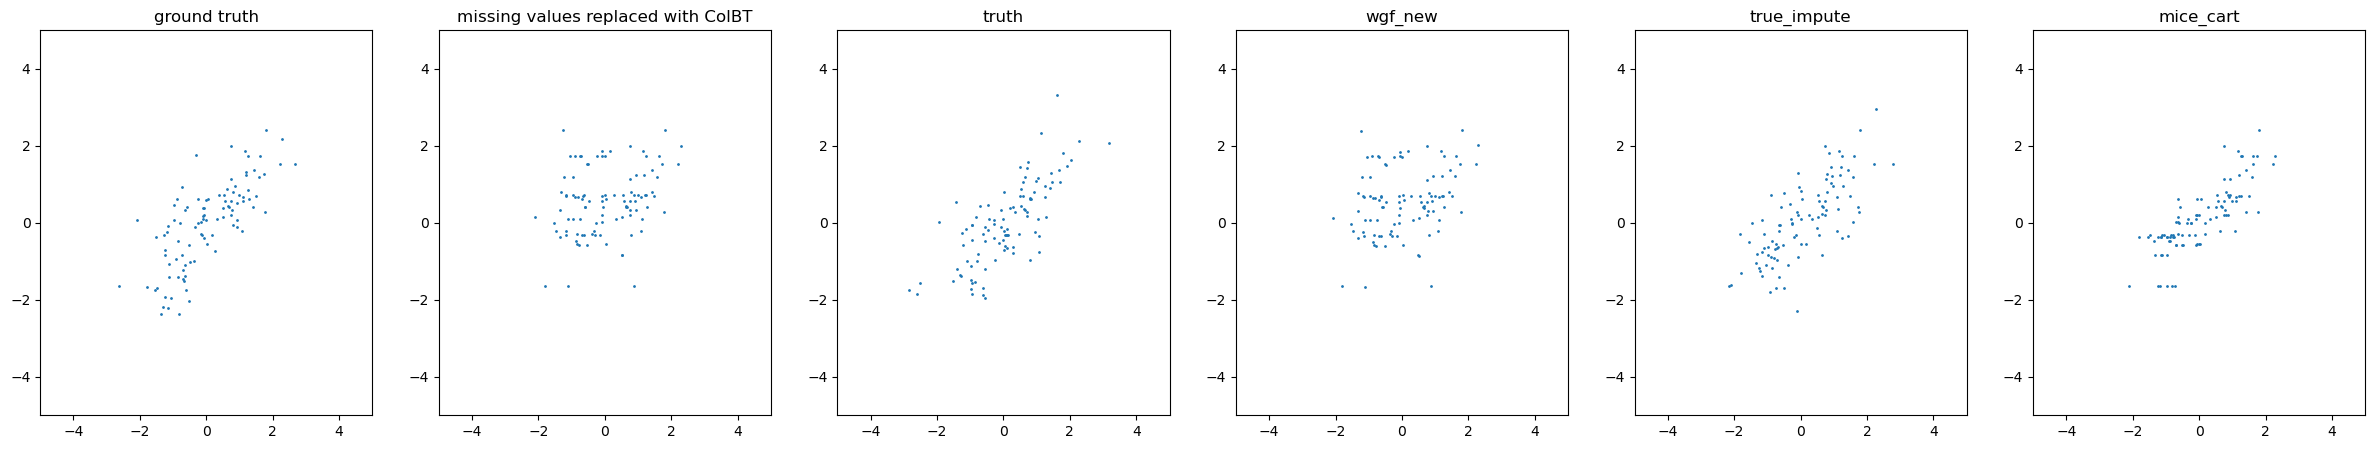

In [35]:
## Plot data points (true, initial imputation, wgf, new true)
plt.figure(figsize=(5*(len(methods)+2), 5))

xymin = -5
xymax = 5

Xstar = results["data"][run]["Xstar"]
plt.subplot(1, len(methods)+2, 1)
plt.scatter(Xstar[:, 0].cpu(), Xstar[:, 1].cpu(), s = 1)
plt.xlim(xymin, xymax); plt.ylim(xymin, xymax)
plt.title("ground truth")

X0 = results["data"][run]["X0"]
plt.subplot(1, len(methods)+2, 2)
plt.scatter(X0[:, 0].detach().cpu(), X0[:, 1].detach().cpu(), s = 1)
plt.xlim(xymin, xymax); plt.ylim(xymin, xymax)
plt.title(f"missing values replaced with {param_vals["init"]}")

for method in methods:
    it = param_vals["T"]-1 if method in ["wgf", "wgf_new"] else 0
    X = results["Xhat_store"][f"{method}_{run}_{it}"]
    plt.subplot(1, len(methods)+2, methods.index(method) + 3)
    plt.scatter(X[:, 0], X[:, 1], s = 1)
    plt.xlim(xymin, xymax); plt.ylim(xymin, xymax)
    plt.title(method)

## Boxplots for RMSE, Energy and Quantile

In [36]:
## Create dataframe with all results
rows = []
for method, recs in results["metrics"].items():
    for r in recs:
        rows.append({**r, "method": method})

results_df = pd.DataFrame(rows)

In [37]:
## Standardize energy
def standardize_negative_score(series):
    neg = -series
    return (neg - neg.min()) / (neg.max() - neg.min()) - 1

results_df['energy_std'] = standardize_negative_score(results_df['energy'])

In [38]:
def standardize_neg_iqr(series, k=1.5):
    neg = -series

    q1 = neg.quantile(0.25)
    q3 = neg.quantile(0.75)
    iqr = q3 - q1

    lo = q1 - k * iqr
    hi = q3 + k * iqr

    neg_clipped = neg.clip(lo, hi)

    return (neg_clipped - lo) / (hi - lo) - 1

results_df['energy_std_iqr'] = standardize_neg_iqr(results_df['energy'])

In [39]:
def boxplot(df, col, only_wgf=False):
    plt.figure(figsize=(8,6))
    if only_wgf:
        sns.boxplot(x="iter", y=col,data=df[df["method"] == "wgf_new"])
        plt.xlabel("WGF Iteration")
        plt.title(f"{col} distribution per iteration")
    else:
        idx = df.groupby(['method', 'run'])['iter'].idxmax()
        df_max = df.loc[idx].reset_index(drop=True)
        sns.boxplot(x="method", y=col, data=df_max)
        plt.xlabel("Imputation Method")
        plt.title(f"{col} distribution per method")
    plt.ylabel(col)
    if col == "quantile":
        if param_vals["distr"] == "UNI":
            plt.axhline(0.1)
            plt.axhline(0.106)
        elif param_vals["distr"] == "Normal":
            plt.axhline(scipy.stats.norm.ppf(0.1))
    # else:
    #     plt.ylim(-1.1, 0.1)
    plt.show() 

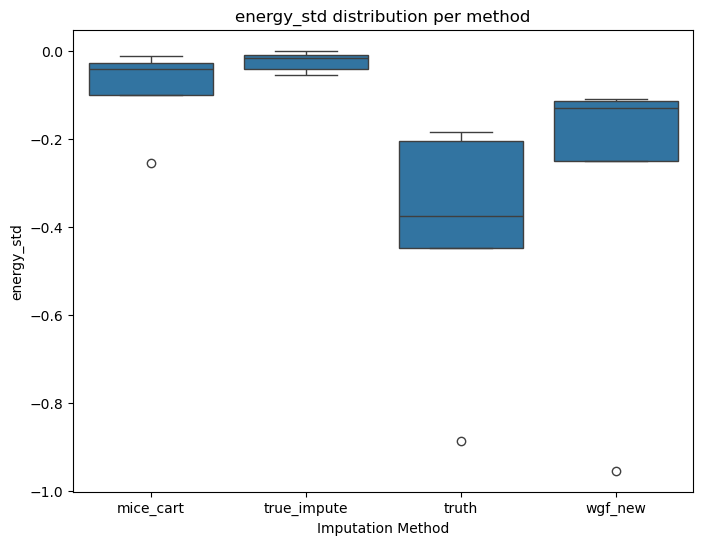

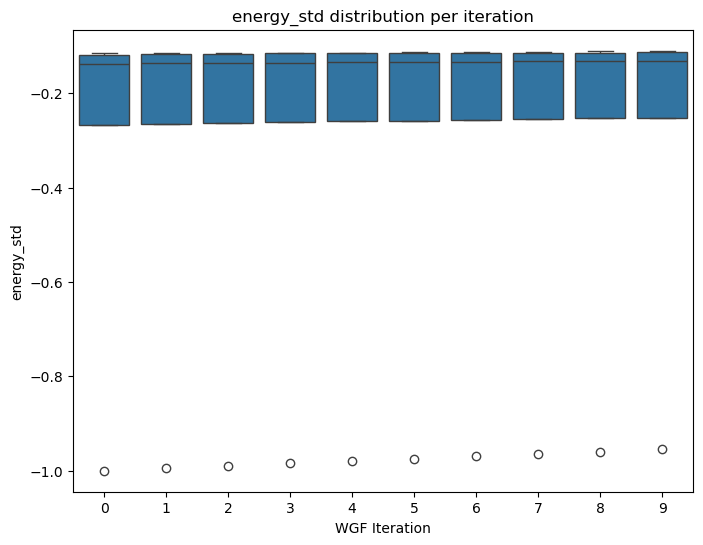

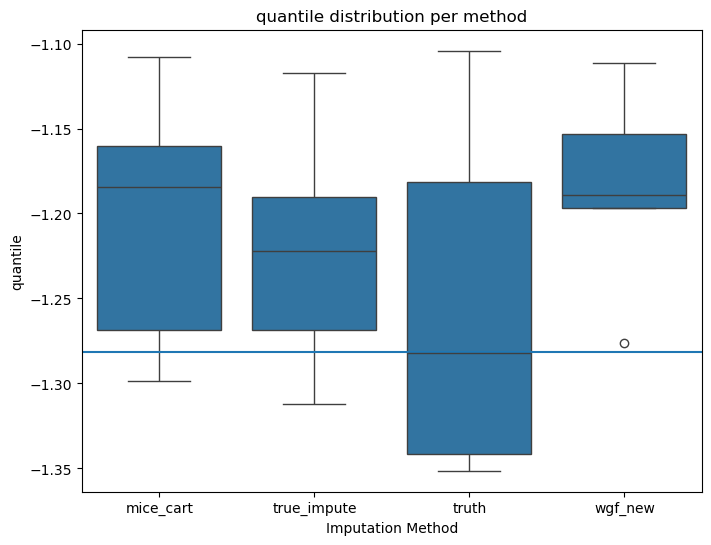

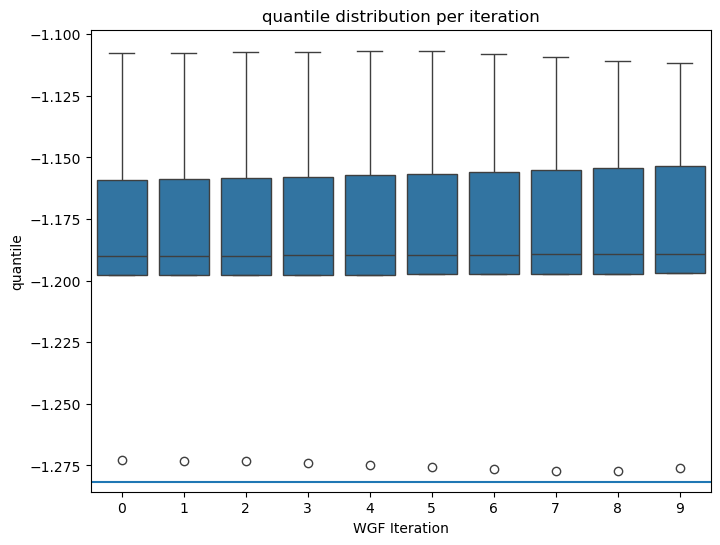

In [40]:
for col in ["energy_std", "quantile"]: #, "energy_std_iqr"]:
    boxplot(results_df, col)
    boxplot(results_df, col, only_wgf=True)